In [1]:
import os, sys, pickle, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from IPython.display import display, Image

os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")
os.environ.setdefault("HF_ENDPOINT", "https://hf-mirror.com")
from transformers import AutoModel

# ── Constants ──────────────────────────────────────────────────────────────────
PKL_PATH      = "./moons.pkl"
TRAIN_DOMAINS = 9
SEED          = 42
RANK          = 8
ALPHA         = 1.0
NUM_CLASSES   = 2
DEVICE        = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ── set_seed ───────────────────────────────────────────────────────────────────
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Device : {DEVICE}")
print(f"Seed   : {SEED}")


Device : cuda:0
Seed   : 42


In [2]:
def load_data(path, n_train):
    print(f"[Data] loading {path} ...")
    with open(path, "rb") as f:
        ds = pickle.load(f)["datasets"]
    train = [(t, torch.FloatTensor(ds[t][0]), torch.LongTensor(ds[t][1]))
             for t in range(n_train)]
    test  = [(t, torch.FloatTensor(ds[t][0]), torch.LongTensor(ds[t][1]))
             for t in range(n_train, n_train + 3)]
    print(f"  train domains: {[t for t,_,_ in train]}")
    print(f"  test  domains: {[t for t,_,_ in test]}")
    return train, test

train_sets, test_sets = load_data(PKL_PATH, TRAIN_DOMAINS)


[Data] loading ./moons.pkl ...
  train domains: [0, 1, 2, 3, 4, 5, 6, 7, 8]
  test  domains: [9, 10, 11]


In [3]:
class FlowCoreLayer(nn.Module):
    def __init__(self, original_layer, rank=8, alpha=1.0):
        super().__init__()
        self.original_layer = original_layer
        self.rank    = rank
        self.scaling = alpha / rank
        in_dim  = original_layer.in_features
        out_dim = original_layer.out_features
        self.down_proj = nn.Parameter(torch.randn(in_dim, rank) * 0.01)
        self.up_proj   = nn.Parameter(torch.zeros(rank, out_dim))
        self.generator = nn.Parameter(torch.randn(rank, rank) * 0.01)
        self.current_t = 0.0

    def set_time(self, t):
        self.current_t = float(t)

    def _make_Ft(self, device, dtype):
        t  = torch.tensor(self.current_t, device=device, dtype=torch.float32)
        W  = self.generator.to(device=device, dtype=torch.float32)
        Ft = torch.linalg.matrix_exp(t * W)
        return Ft.to(dtype=dtype)

    def forward(self, x):
        y  = self.original_layer(x)
        Ft = self._make_Ft(x.device, x.dtype)
        h  = x @ self.down_proj.to(x.dtype)
        h  = h @ Ft
        return y + (h @ self.up_proj.to(x.dtype)) * self.scaling


def _get_parent(model, name):
    parts, parent = name.split("."), model
    for p in parts[:-1]:
        parent = getattr(parent, p)
    return parent, parts[-1]


def apply_flow_core(model, target_suffixes, rank=8, alpha=1.0):
    names = [n for n, m in model.named_modules()
             if isinstance(m, nn.Linear)
             and any(n.endswith(s) for s in target_suffixes)]
    for name in names:
        parent, attr = _get_parent(model, name)
        setattr(parent, attr,
                FlowCoreLayer(getattr(parent, attr), rank=rank, alpha=alpha))
    print(f"  [FlowCore] replaced {len(names)} layers")
    return model


def set_time_all(model, t):
    for m in model.modules():
        if isinstance(m, FlowCoreLayer):
            m.set_time(t)


def resolve_model_name(backbone):
    return {
        "distilbert": "distilbert-base-uncased",
        "llama3":     "meta-llama/Meta-Llama-3-8B",
        "tinyllama":  "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T",
        "qwen":       "Qwen/Qwen3-0.6B",
    }[backbone]


def get_targets(backbone):
    if backbone == "distilbert":
        return ("q_lin", "k_lin", "v_lin", "lin1", "lin2")
    return ("q_proj", "k_proj", "v_proj", "gate_proj", "up_proj", "down_proj")


class MaT_net(nn.Module):
    def __init__(self, backbone, model_name, num_classes, rank=8, alpha=1.0):
        super().__init__()
        self.backbone = backbone
        print(f"  [MaT_net] loading {model_name} ...")
        self.featurizer = AutoModel.from_pretrained(model_name)
        for p in self.featurizer.parameters():
            p.requires_grad = False
        hidden = self.featurizer.config.hidden_size
        self.coord_proj = nn.Linear(2, hidden)
        self.classifier  = nn.Linear(hidden, num_classes)
        apply_flow_core(self, get_targets(backbone), rank=rank, alpha=alpha)

    def set_time(self, t):
        set_time_all(self, t)

    def forward(self, x):
        embeds = self.coord_proj(x)
        ftype  = next(self.featurizer.parameters()).dtype
        out    = self.featurizer(inputs_embeds=embeds.unsqueeze(1).to(ftype))
        if self.backbone in ("llama3", "tinyllama", "qwen"):
            feat = out.last_hidden_state[:, -1, :].float()
        else:
            feat = out.last_hidden_state[:, 0, :].float()
        return self.classifier(feat)

print("[Model] MaT_net defined.")


[Model] MaT_net defined.


In [4]:
def train_model(model, train_sets, lr, epochs, device, print_every=10):
    """Full training loop — no mid-training evaluation."""
    optimizer = optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr, weight_decay=1e-4,
    )
    criterion = nn.CrossEntropyLoss()
    model.train()
    for epoch in range(1, epochs + 1):
        total_loss = 0.0
        for t, X, y in train_sets:
            model.set_time(int(t))
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(X.to(device)), y.to(device))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if epoch % print_every == 0 or epoch == 1 or epoch == epochs:
            print(f"  ep={epoch:4d}/{epochs}  "
                  f"avg_loss={total_loss/len(train_sets):.4f}")
    print("[Training Done]")

print("[Train] train_model defined.")


[Train] train_model defined.


In [5]:
@torch.no_grad()
def eval_extrap(model, test_sets, device):
    """Single evaluation pass on test domains."""
    model.eval()
    accs = {}
    for t, X, y in test_sets:
        model.set_time(int(t))
        preds = torch.argmax(model(X.to(device)), dim=1)
        accs[int(t)] = float((preds == y.to(device)).float().mean())
    avg = sum(accs.values()) / max(len(accs), 1)
    detail = "  ".join(f"domain{t}={v:.4f}" for t, v in sorted(accs.items()))
    print(f"  avg_acc={avg:.4f}  |  {detail}")
    model.train()
    return accs, avg

print("[Eval] eval_extrap defined.")


[Eval] eval_extrap defined.


In [6]:
DISPLAY_NAME = {
    "distilbert": "DistilBERT",
    "tinyllama":  "TinyLLaMA",
    "qwen":       "Qwen",
    "llama3":     "LLaMA3",
}

def _forward_grid(model, grid_cpu, device, chunk=2048):
    outs = []
    for i in range(0, len(grid_cpu), chunk):
        outs.append(model(grid_cpu[i:i+chunk].to(device)).detach().cpu())
    return torch.cat(outs, 0)


def plot_result(model, backbone, test_sets, device, out_path,
                plot_lim=2.5, grid_step=0.02, grid_chunk=2048):
    """Decision boundary plot: 1 row x 3 cols (Extrapolate 1/2/3)."""
    region_cmap = ListedColormap(["#F2E98E", "#B8B2D8"])
    pt_cmap     = ListedColormap(["#B9A800", "#5E4FA2"])

    plt.rcParams.update({"font.size": 14, "font.weight": "bold",
                          "axes.titleweight": "bold"})

    n_cols = len(test_sets)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols + 2, 5))
    if n_cols == 1:
        axes = [axes]

    xx, yy = np.meshgrid(
        np.arange(-plot_lim, plot_lim + 1e-9, grid_step),
        np.arange(-plot_lim, plot_lim + 1e-9, grid_step),
    )
    grid_cpu = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

    row_accs = []
    model.eval()
    with torch.no_grad():
        for j, (t, X, y) in enumerate(test_sets):
            ax  = axes[j]
            t_i = int(t)
            model.set_time(t_i)
            ax.set_title(f"Extrapolate {j+1}", fontsize=20, fontweight="bold", pad=10)

            # decision region
            logits_g = _forward_grid(model, grid_cpu, device, grid_chunk)
            preds_g  = np.argmax(logits_g.numpy(), axis=1).reshape(xx.shape)
            ax.contourf(xx, yy, preds_g, levels=[-0.5,0.5,1.5],
                        cmap=region_cmap, alpha=1.0)
            prob1 = torch.softmax(logits_g, 1)[:,1].numpy().reshape(xx.shape)
            ax.contour(xx, yy, prob1, levels=[0.5],
                       colors=["red"], linewidths=4.0)

            # scatter
            Xn, yn = X.numpy(), y.numpy()
            for cls, c in enumerate(pt_cmap.colors):
                m = yn == cls
                ax.scatter(Xn[m,0], Xn[m,1], s=22, c=c,
                           edgecolors="white", linewidths=0.5)

            # accuracy
            pred_y = torch.argmax(model(X.to(device)), 1).cpu()
            acc    = float((pred_y == y).float().mean())
            row_accs.append(acc)

            ax.text(0.97, 0.97, f"acc: {acc*100:.2f}%",
                    transform=ax.transAxes, ha="right", va="top",
                    fontsize=16, fontweight="bold",
                    bbox=dict(facecolor="white", edgecolor="black",
                              linewidth=3.0, boxstyle="round,pad=0.3"))
            ax.set_xlim(-plot_lim, plot_lim)
            ax.set_ylim(-plot_lim, plot_lim)
            ax.tick_params(axis="both", width=2.5, length=8, labelsize=11)
            for sp in ax.spines.values():
                sp.set_linewidth(3.5)

    avg_acc = sum(row_accs) / len(row_accs)
    bb = axes[0].get_position()
    yc = (bb.y0 + bb.y1) / 2.0
    fig.text(0.005, yc + 0.04, DISPLAY_NAME.get(backbone, backbone),
             ha="left", va="center", fontsize=20, fontweight="bold")
    fig.text(0.005, yc - 0.06, f"Avg acc:\n{avg_acc*100:.2f}%",
             ha="left", va="center", fontsize=15, fontweight="bold")

    legend_handles = [
        Line2D([0],[0], marker="o", color="w", label="Label 0",
               markerfacecolor=pt_cmap.colors[0], markersize=11),
        Line2D([0],[0], marker="o", color="w", label="Label 1",
               markerfacecolor=pt_cmap.colors[1], markersize=11),
    ]
    fig.legend(handles=legend_handles, loc="lower center", ncol=2,
               frameon=False, fontsize=14,
               bbox_to_anchor=(0.5, -0.02))
    plt.subplots_adjust(left=0.13, bottom=0.17, top=0.92, wspace=0.15)

    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"[Plot] saved -> {out_path}")
    model.train()

print("[Plot] plot_result defined.")


[Plot] plot_result defined.


  [MaT_net] loading distilbert-base-uncased ...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

  [FlowCore] replaced 30 layers

[DistilBERT] lr=0.001  epochs=500
  ep=   1/500  avg_loss=0.7004
  ep=  10/500  avg_loss=0.5563
  ep=  20/500  avg_loss=0.0994
  ep=  30/500  avg_loss=0.0373
  ep=  40/500  avg_loss=0.0223
  ep=  50/500  avg_loss=0.0226
  ep=  60/500  avg_loss=0.0133
  ep=  70/500  avg_loss=0.0164
  ep=  80/500  avg_loss=0.0254
  ep=  90/500  avg_loss=0.0124
  ep= 100/500  avg_loss=0.0037
  ep= 110/500  avg_loss=0.1447
  ep= 120/500  avg_loss=0.0131
  ep= 130/500  avg_loss=0.0099
  ep= 140/500  avg_loss=0.0054
  ep= 150/500  avg_loss=0.0037
  ep= 160/500  avg_loss=0.0332
  ep= 170/500  avg_loss=0.0021
  ep= 180/500  avg_loss=0.0025
  ep= 190/500  avg_loss=0.0085
  ep= 200/500  avg_loss=0.0031
  ep= 210/500  avg_loss=0.0010
  ep= 220/500  avg_loss=0.0079
  ep= 230/500  avg_loss=0.0009
  ep= 240/500  avg_loss=0.0031
  ep= 250/500  avg_loss=0.0003
  ep= 260/500  avg_loss=0.0340
  ep= 270/500  avg_loss=0.0064
  ep= 280/500  avg_loss=0.0005
  ep= 290/500  avg_loss=0.0031
  e

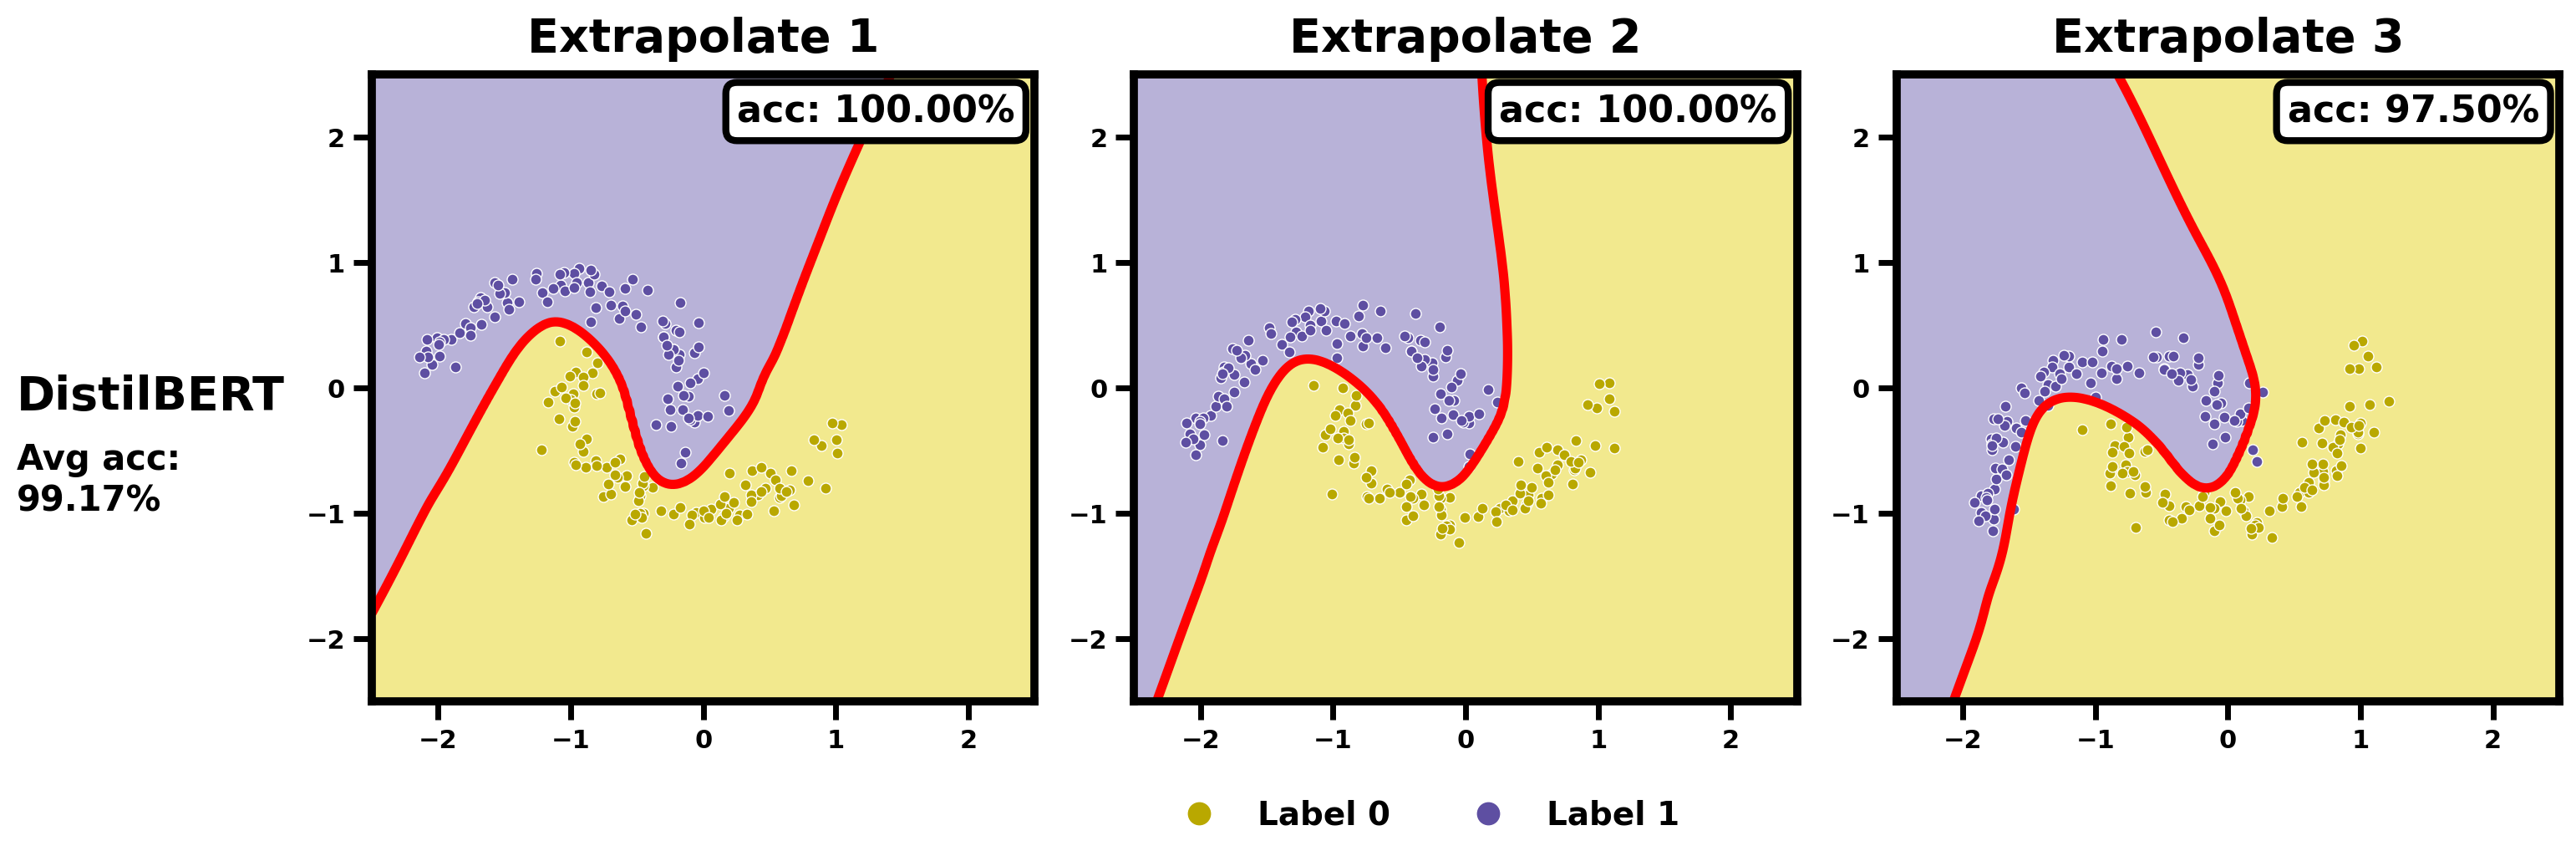


[DistilBERT] Done. GPU memory released.


In [7]:
# ── DistilBERT: lr=1e-3, epochs=500 ───────────────────────────────────────────
LR     = 1e-3
EPOCHS = 500

set_seed(SEED)
model_db = MaT_net("distilbert", resolve_model_name("distilbert"),
                    NUM_CLASSES, rank=RANK, alpha=ALPHA).to(DEVICE)
print(f"\n[DistilBERT] lr={LR}  epochs={EPOCHS}")
train_model(model_db, train_sets, LR, EPOCHS, DEVICE)
print("\n[DistilBERT] Final evaluation:")
accs_db, avg_db = eval_extrap(model_db, test_sets, DEVICE)
out_db = "./figures/distilbert.png"
plot_result(model_db, "distilbert", test_sets, DEVICE, out_db)
display(Image(out_db))
model_db.to("cpu"); del model_db; torch.cuda.empty_cache()
print("\n[DistilBERT] Done. GPU memory released.")


  [MaT_net] loading TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T ...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

  [FlowCore] replaced 132 layers

[TinyLLaMA] lr=0.0004  epochs=200
  ep=   1/200  avg_loss=0.7359
  ep=  10/200  avg_loss=0.1083
  ep=  20/200  avg_loss=0.1181
  ep=  30/200  avg_loss=0.0103
  ep=  40/200  avg_loss=0.0037
  ep=  50/200  avg_loss=0.0020
  ep=  60/200  avg_loss=0.0014
  ep=  70/200  avg_loss=0.0055
  ep=  80/200  avg_loss=0.0020
  ep=  90/200  avg_loss=0.0012
  ep= 100/200  avg_loss=0.0008
  ep= 110/200  avg_loss=0.0005
  ep= 120/200  avg_loss=0.0004
  ep= 130/200  avg_loss=0.0003
  ep= 140/200  avg_loss=0.0002
  ep= 150/200  avg_loss=0.0002
  ep= 160/200  avg_loss=0.0001
  ep= 170/200  avg_loss=0.0001
  ep= 180/200  avg_loss=0.0001
  ep= 190/200  avg_loss=0.0001
  ep= 200/200  avg_loss=0.0001
[Training Done]

[TinyLLaMA] Final evaluation:
  avg_acc=0.9600  |  domain9=0.9950  domain10=0.9800  domain11=0.9050
[Plot] saved -> ./figures/tinyllama.png


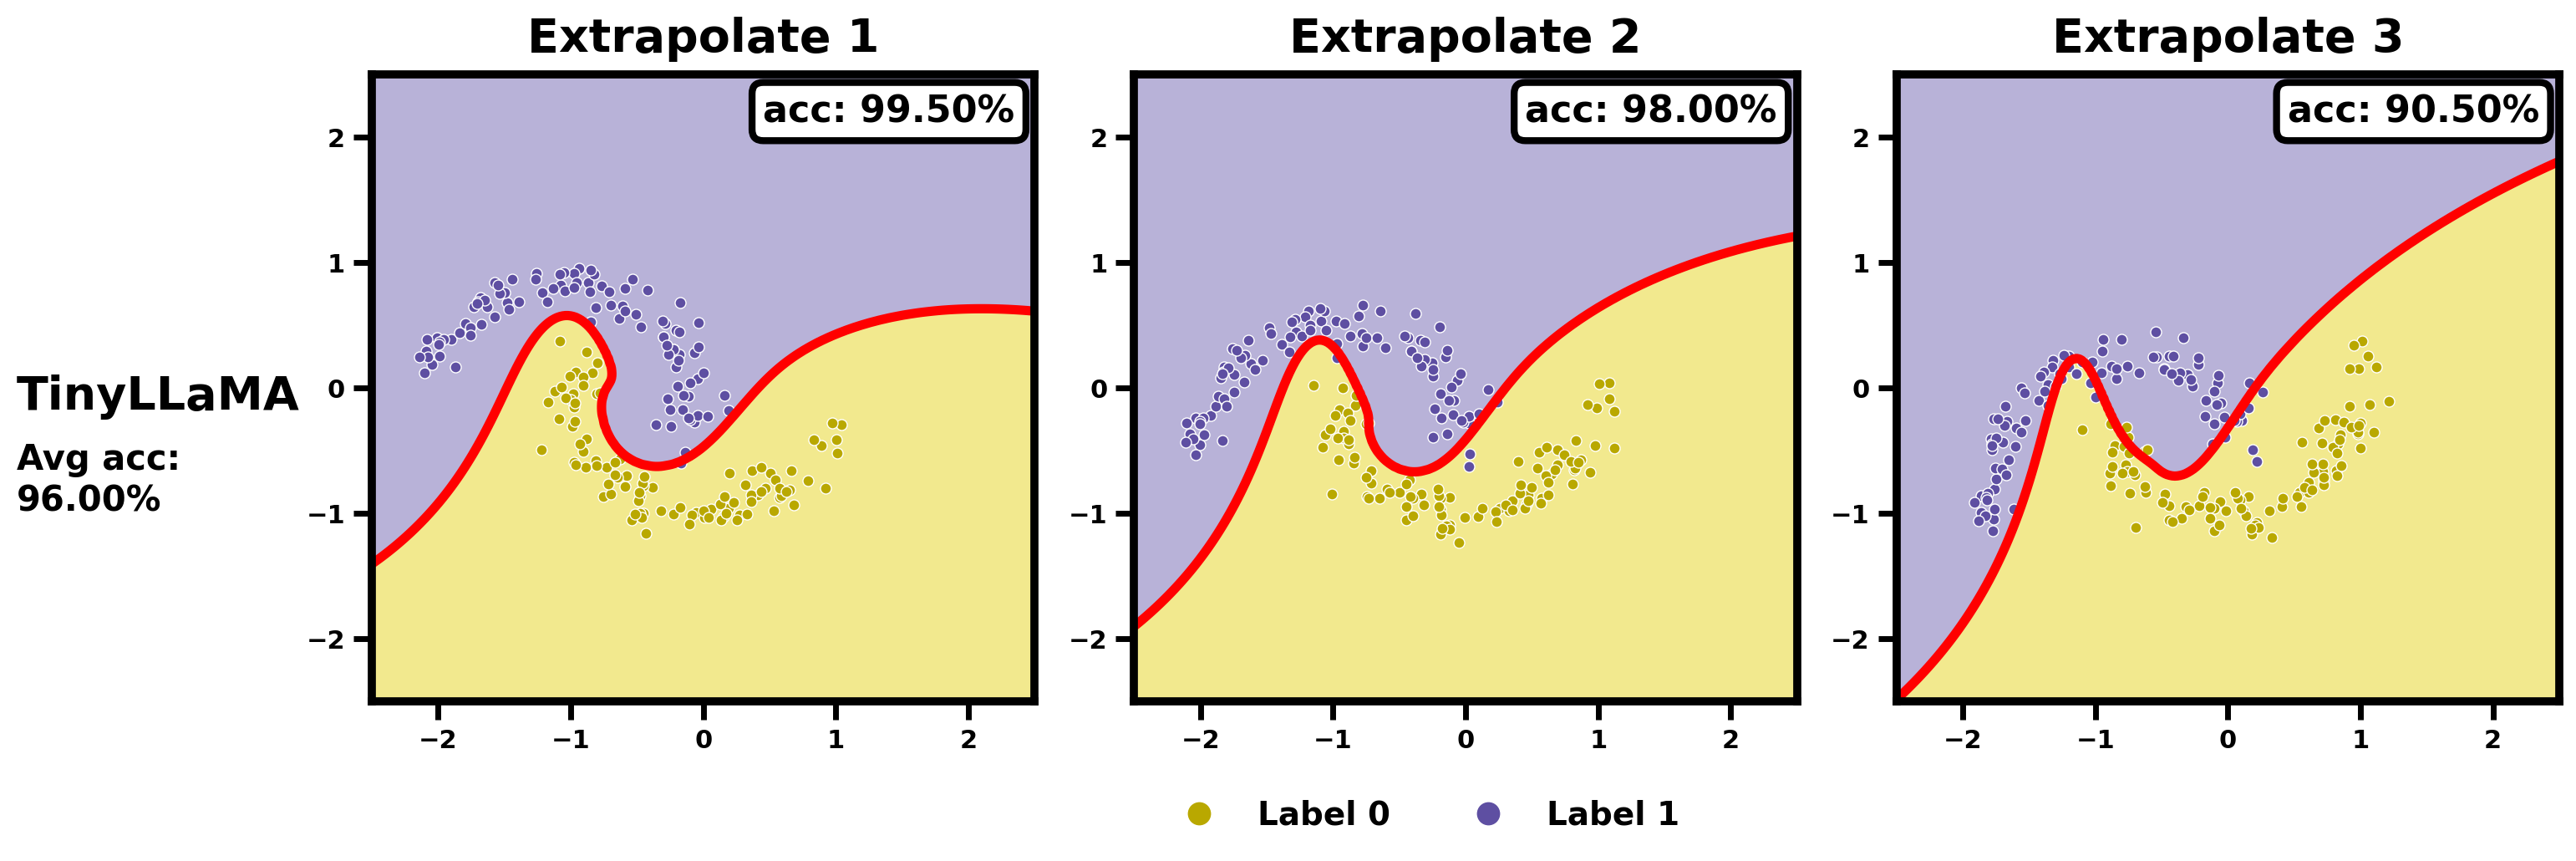


[TinyLLaMA] Done. GPU memory released.


In [8]:
# ── TinyLLaMA: lr=4e-4, epochs=200 ───────────────────────────────────────────
LR     = 4e-4
EPOCHS = 200

set_seed(SEED)
model_tl = MaT_net("tinyllama", resolve_model_name("tinyllama"),
                    NUM_CLASSES, rank=RANK, alpha=ALPHA).to(DEVICE)
print(f"\n[TinyLLaMA] lr={LR}  epochs={EPOCHS}")
train_model(model_tl, train_sets, LR, EPOCHS, DEVICE)
print("\n[TinyLLaMA] Final evaluation:")
accs_tl, avg_tl = eval_extrap(model_tl, test_sets, DEVICE)
out_tl = "./figures/tinyllama.png"
plot_result(model_tl, "tinyllama", test_sets, DEVICE, out_tl)
display(Image(out_tl))
model_tl.to("cpu"); del model_tl; torch.cuda.empty_cache()
print("\n[TinyLLaMA] Done. GPU memory released.")


  [MaT_net] loading Qwen/Qwen3-0.6B ...


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  [FlowCore] replaced 168 layers

[Qwen] lr=0.005  epochs=20
  ep=   1/20  avg_loss=1.5662
  ep=  10/20  avg_loss=0.2486
  ep=  20/20  avg_loss=0.2171
[Training Done]

[Qwen] Final evaluation:
  avg_acc=0.9550  |  domain9=0.9850  domain10=0.9850  domain11=0.8950
[Plot] saved -> ./figures/qwen.png


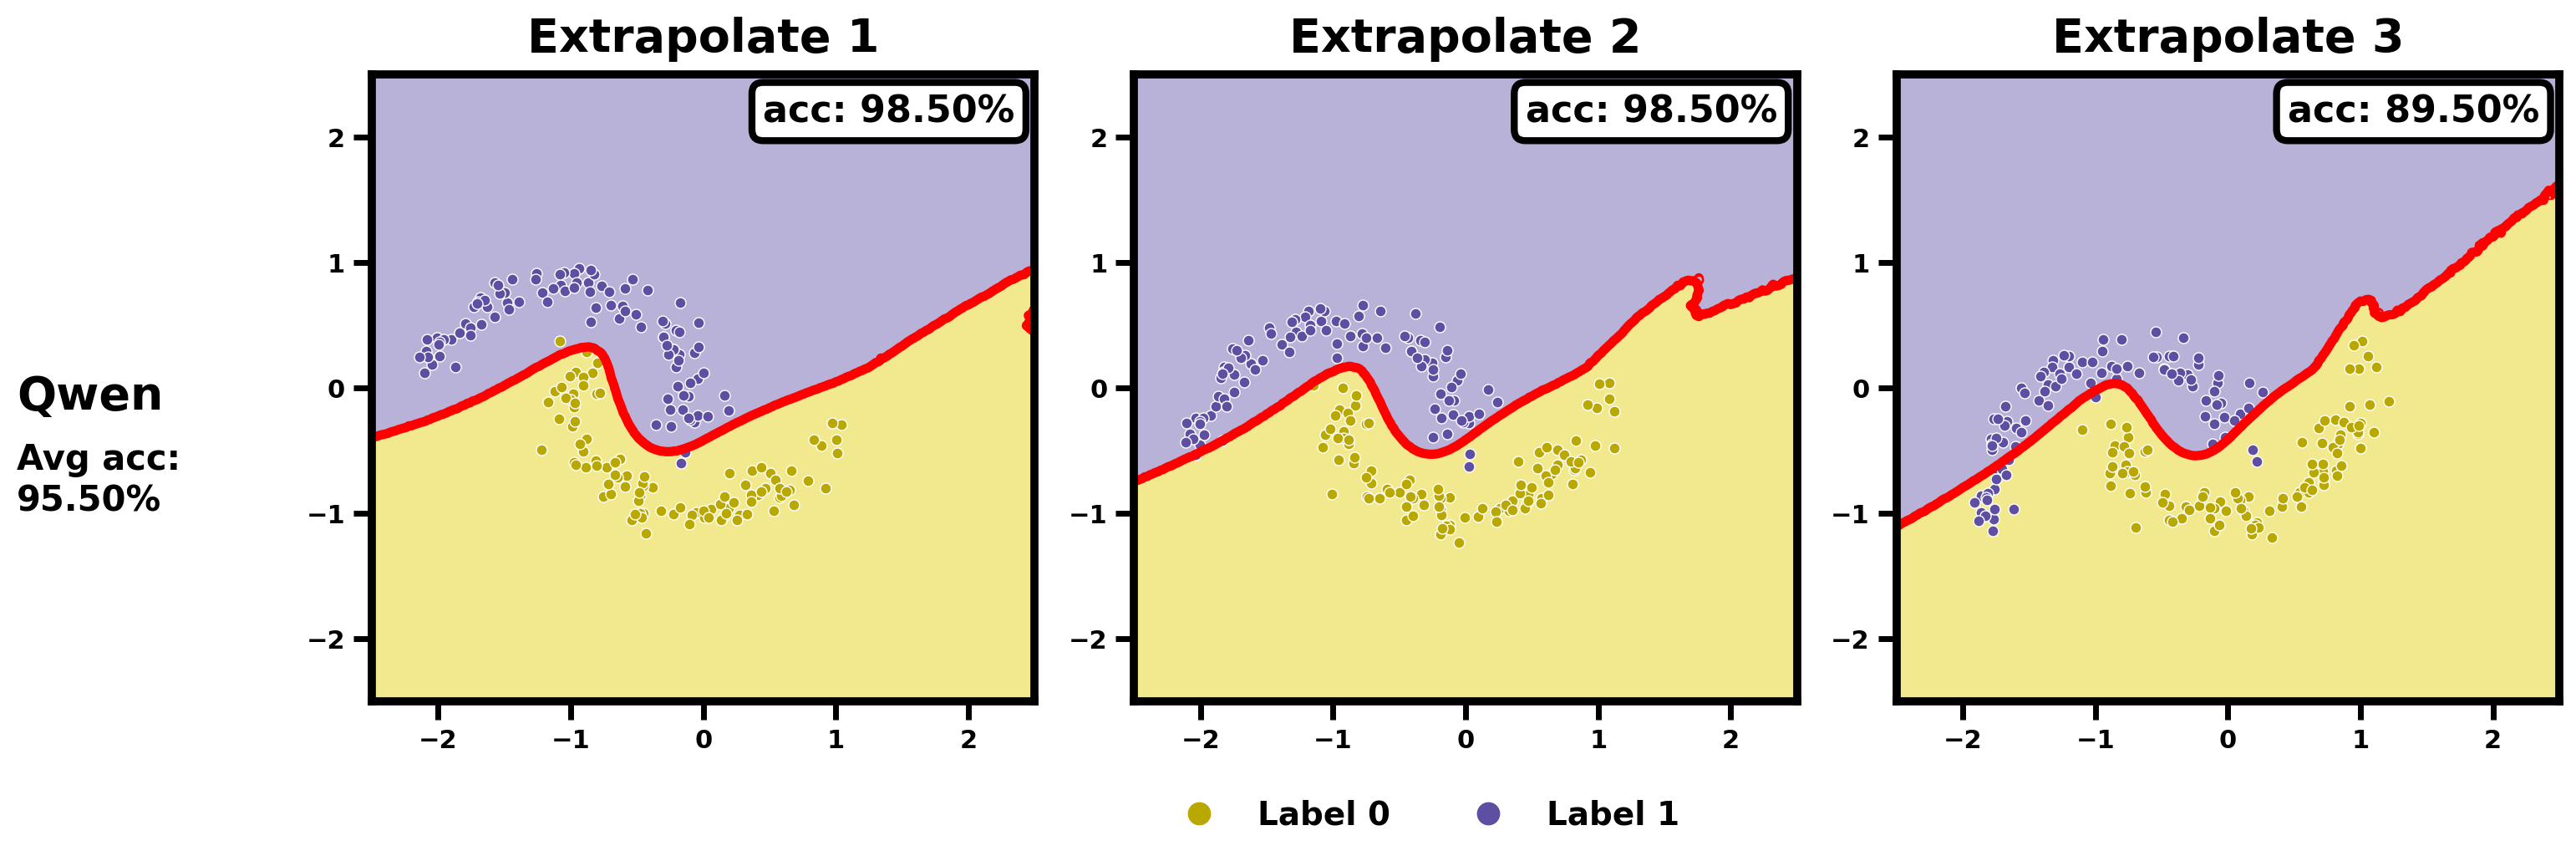


[Qwen] Done. GPU memory released.


In [9]:
# ── Qwen: lr=5e-3, epochs=20 ──────────────────────────────────────────────────
LR     = 5e-3
EPOCHS = 20

set_seed(SEED)
model_qw = MaT_net("qwen", resolve_model_name("qwen"),
                    NUM_CLASSES, rank=RANK, alpha=ALPHA).to(DEVICE)
print(f"\n[Qwen] lr={LR}  epochs={EPOCHS}")
train_model(model_qw, train_sets, LR, EPOCHS, DEVICE)
print("\n[Qwen] Final evaluation:")
accs_qw, avg_qw = eval_extrap(model_qw, test_sets, DEVICE)
out_qw = "./figures/qwen.png"
plot_result(model_qw, "qwen", test_sets, DEVICE, out_qw)
display(Image(out_qw))
model_qw.to("cpu"); del model_qw; torch.cuda.empty_cache()
print("\n[Qwen] Done. GPU memory released.")


  [MaT_net] loading meta-llama/Meta-Llama-3-8B ...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

  [FlowCore] replaced 192 layers

[LLaMA3] lr=0.002  epochs=50
  ep=   1/50  avg_loss=1.3410
  ep=  10/50  avg_loss=0.6752
  ep=  20/50  avg_loss=0.6169
  ep=  30/50  avg_loss=0.3627
  ep=  40/50  avg_loss=0.0064
  ep=  50/50  avg_loss=0.0022
[Training Done]

[LLaMA3] Final evaluation:
  avg_acc=0.9383  |  domain9=0.9850  domain10=0.9550  domain11=0.8750
[Plot] saved -> ./figures/llama3.png


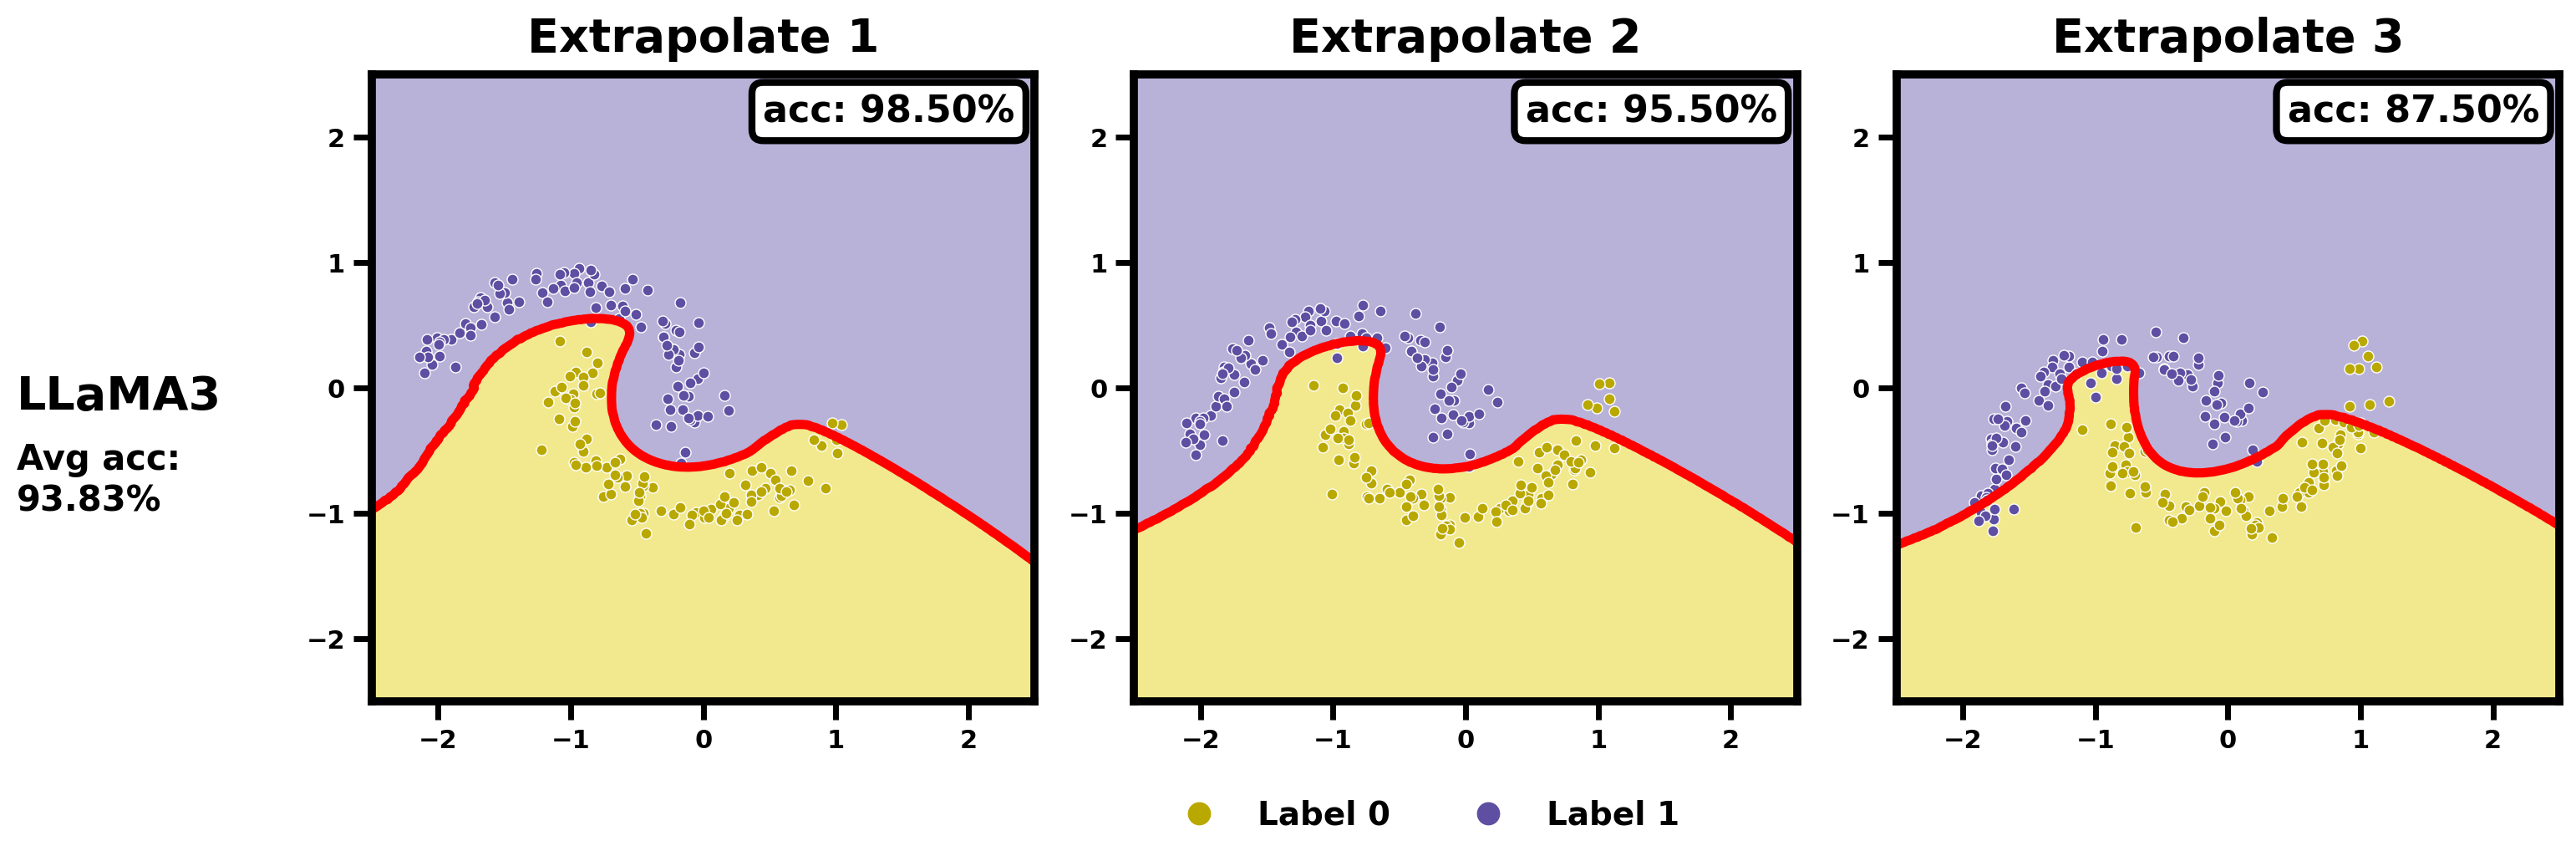


[LLaMA3] Done. GPU memory released.


In [10]:
# ── LLaMA3: lr=2e-3, epochs=50 ───────────────────────────────────────────────
LR     = 2e-3
EPOCHS = 50

set_seed(SEED)
model_l3 = MaT_net("llama3", resolve_model_name("llama3"),
                    NUM_CLASSES, rank=RANK, alpha=ALPHA).to(DEVICE)
print(f"\n[LLaMA3] lr={LR}  epochs={EPOCHS}")
train_model(model_l3, train_sets, LR, EPOCHS, DEVICE)
print("\n[LLaMA3] Final evaluation:")
accs_l3, avg_l3 = eval_extrap(model_l3, test_sets, DEVICE)
out_l3 = "./figures/llama3.png"
plot_result(model_l3, "llama3", test_sets, DEVICE, out_l3)
display(Image(out_l3))
model_l3.to("cpu"); del model_l3; torch.cuda.empty_cache()
print("\n[LLaMA3] Done. GPU memory released.")
